In [55]:
import psi4
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
%load_ext autoreload
%autoreload 2
from src.lps_rscf import lps_solver
from src.plot_iter import plot_iter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Number of basis functions:   31

Starting SCF iterations:

    Iter               Energy         ChemPot       Delta E         dRMS

SCF Iter  1:      1108.67624786   -5.00000E+01    1.10868E+03    9.14333E+01
SCF Iter  2:       889.07501910    2.09376E-02   -2.19601E+02    7.64348E+01
SCF Iter  3:       709.25685328   -2.11048E-01   -1.79818E+02    6.39006E+01
SCF Iter  4:      1069.95797045   -3.77092E+02    3.60701E+02    8.54327E+01
SCF Iter  5:      1054.95450475   -5.08858E+01   -1.50035E+01    8.45632E+01
SCF Iter  6:       957.48738318   -2.84988E+01   -9.74671E+01    7.80355E+01
SCF Iter  7:       808.92166773   -1.45315E+01   -1.48566E+02    6.75410E+01
SCF Iter  8:       652.18395667   -3.20820E+00   -1.56738E+02    5.65965E+01
SCF Iter  9:       519.10835677   -6.42810E-02   -1.33076E+02    4.74239E+01
SCF Iter 10:       412.35379080   -3.58014E+00   -1.06755E+02    3.97623E+01
SCF Iter 11:       324.58355421   -2.77054E+00   -8.77702E+01    3.33412E+01
SCF Iter 12:       2

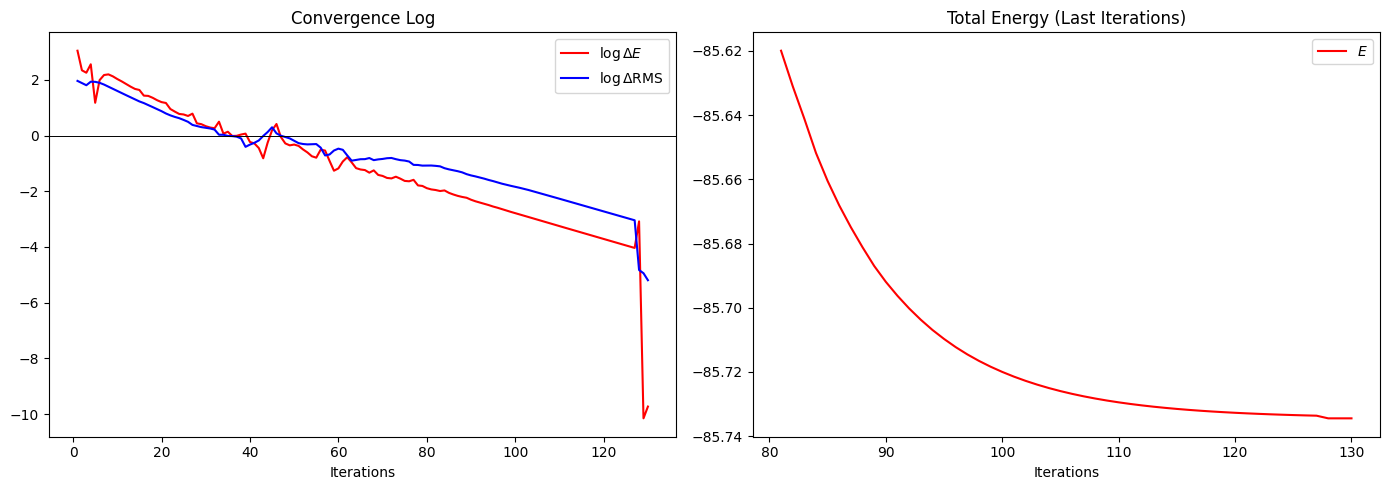

In [ ]:
psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

atom_label, multip = 'Ne', 1
mol = psi4.geometry(f"0 {multip}\n {atom_label}\nsymmetry c1")

E, D, mu, iterations, e_list, e_conv, d_conv = lps_solver(
    mol=mol,
    E_conv=1.0e-5,
    D_conv=1.0e-5,
    maxiter=1000,
    TP=['LDA_K_TF', 1.0],
    lam=1.0,
    EXC=['LDA_X', 1.0, 'LDA_C_VWN', 0.0],
    FA=[False, 1.0],
    damp=[0.9, 0.0, 0.001],
    Guess=None,
    DIIS=True,
    verbose=False
)
print('\nFinal SCF energy: %.4f Hartree' \
      ' in %.i iterations' % ( E, iterations))

plot_iter(iterations, e_conv, d_conv, e_list, 50)

In [49]:
D_guess = D

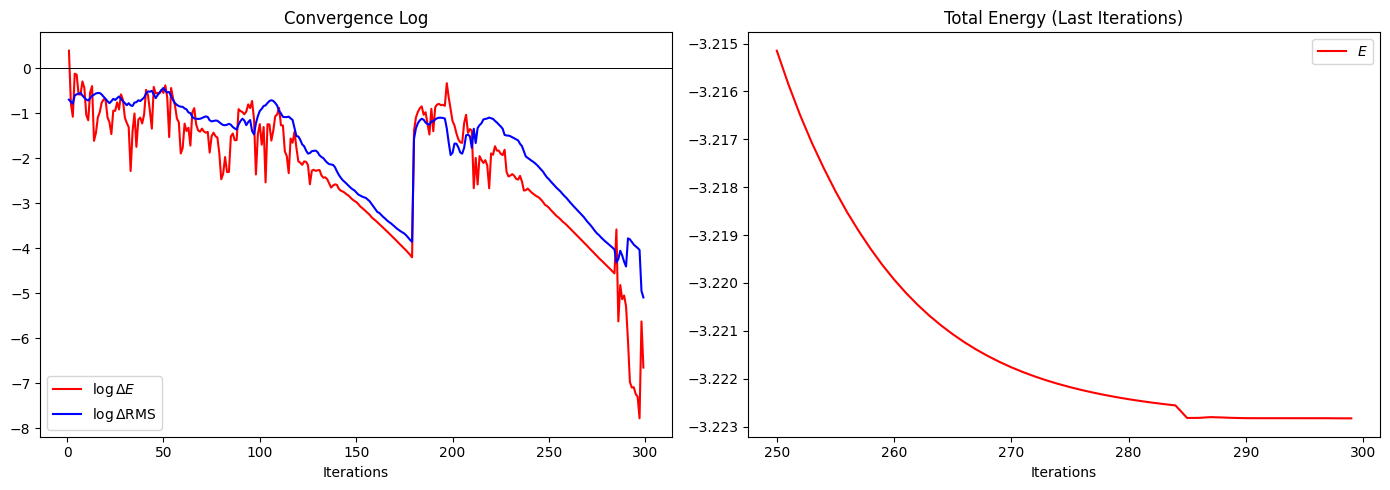

In [10]:
plot_iter(iterations, e_conv, d_conv, e_list, 50)